# Example 5.4: Illustration of Early Stopping and Weight Decay on CIFAR10 dataset

In [1]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
from common_utils import NeuralNetwork, NeuralNetwork_dropout, EarlyStopper
from common_utils import train_loop, test_loop
from common_utils import device, set_seed

In [2]:
set_seed(0)
print(f"Using device: {device}")

Using device: mps


In [3]:
batch_size = 256
max_epochs = 100

lr = 0.001
patience = 10
weight_decay = 0.01
hidden_size = 400

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

In [5]:
model = NeuralNetwork(hidden_size=hidden_size)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr_loss, tr_correct = [], []
te_loss, te_correct = [], []
for epoch in range(max_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr_loss.append(train_loss), tr_correct.append(train_correct)
    te_loss.append(test_loss), te_correct.append(test_correct)
    
    
    print(f"Epoch {epoch+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 41.06%, Train_loss: 0.006517, Test_accuracy: 46.60%, Test_loss: 0.005992
Epoch 2: Train_accuracy: 49.77%, Train_loss: 0.005564, Test_accuracy: 51.17%, Test_loss: 0.005571
Epoch 3: Train_accuracy: 54.11%, Train_loss: 0.005097, Test_accuracy: 51.67%, Test_loss: 0.005519
Epoch 4: Train_accuracy: 57.67%, Train_loss: 0.004680, Test_accuracy: 53.74%, Test_loss: 0.005248
Epoch 5: Train_accuracy: 60.66%, Train_loss: 0.004329, Test_accuracy: 52.51%, Test_loss: 0.005476
Epoch 6: Train_accuracy: 63.93%, Train_loss: 0.003972, Test_accuracy: 53.88%, Test_loss: 0.005436
Epoch 7: Train_accuracy: 66.73%, Train_loss: 0.003641, Test_accuracy: 54.22%, Test_loss: 0.005510
Epoch 8: Train_accuracy: 69.75%, Train_loss: 0.003285, Test_accuracy: 55.49%, Test_loss: 0.005567
Epoch 9: Train_accuracy: 73.22%, Train_loss: 0.002923, Test_accuracy: 54.04%, Test_loss: 0.005930
Epoch 10: Train_accuracy: 76.29%, Train_loss: 0.002617, Test_accuracy: 54.44%, Test_loss: 0.006321
Epoch 11: Train_acc

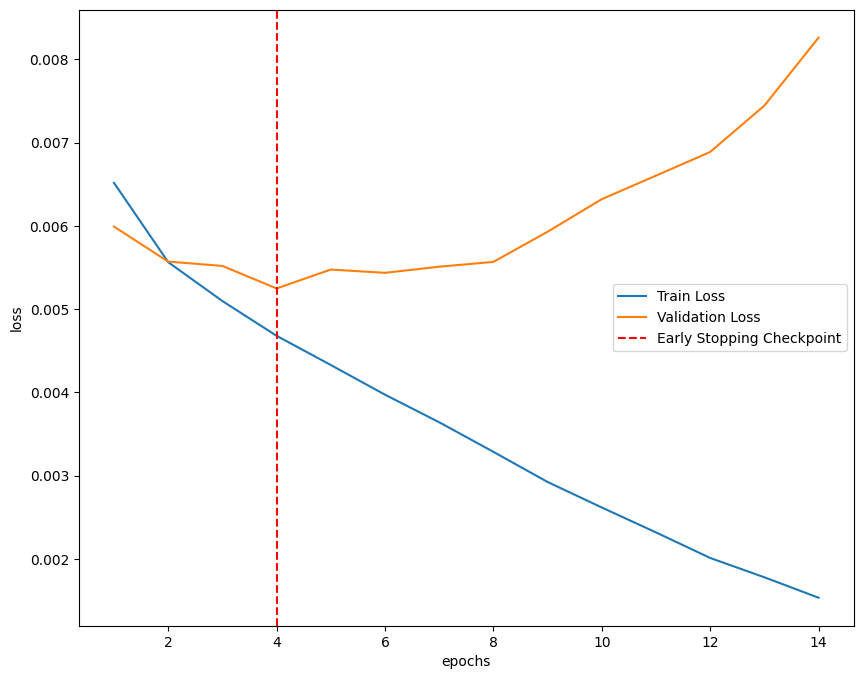

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr_loss)+1),tr_loss, label='Train Loss')
plt.plot(range(1,len(te_loss)+1),te_loss,label='Validation Loss')

# find position of lowest validation loss
minposs = te_loss.index(min(te_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [7]:
model = NeuralNetwork(hidden_size=hidden_size)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr1_loss, tr1_correct = [], []
te1_loss, te1_correct = [], []
for t in range(max_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr1_loss.append(train_loss), tr1_correct.append(train_correct)
    te1_loss.append(test_loss), te1_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 36.41%, Train_loss: 0.006933, Test_accuracy: 39.59%, Test_loss: 0.006800
Epoch 2: Train_accuracy: 41.83%, Train_loss: 0.006400, Test_accuracy: 43.21%, Test_loss: 0.006319
Epoch 3: Train_accuracy: 43.32%, Train_loss: 0.006225, Test_accuracy: 45.37%, Test_loss: 0.006145
Epoch 4: Train_accuracy: 44.60%, Train_loss: 0.006078, Test_accuracy: 44.49%, Test_loss: 0.006190
Epoch 5: Train_accuracy: 45.75%, Train_loss: 0.005973, Test_accuracy: 46.32%, Test_loss: 0.006051
Epoch 6: Train_accuracy: 46.20%, Train_loss: 0.005920, Test_accuracy: 46.69%, Test_loss: 0.006051
Epoch 7: Train_accuracy: 46.74%, Train_loss: 0.005875, Test_accuracy: 46.18%, Test_loss: 0.006090
Epoch 8: Train_accuracy: 47.14%, Train_loss: 0.005837, Test_accuracy: 47.64%, Test_loss: 0.005954
Epoch 9: Train_accuracy: 47.26%, Train_loss: 0.005799, Test_accuracy: 46.95%, Test_loss: 0.006030
Epoch 10: Train_accuracy: 47.71%, Train_loss: 0.005784, Test_accuracy: 47.15%, Test_loss: 0.005961
Epoch 11: Train_acc

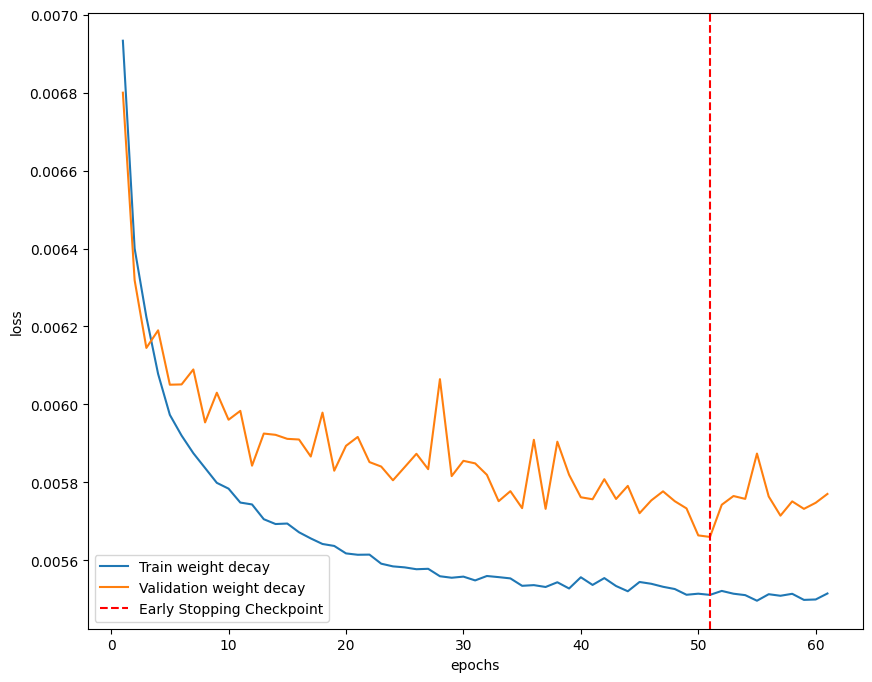

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr1_loss)+1),tr1_loss, label='Train weight decay')
plt.plot(range(1,len(te1_loss)+1),te1_loss,label='Validation weight decay')

# find position of lowest validation loss
minposs = te1_loss.index(min(te1_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

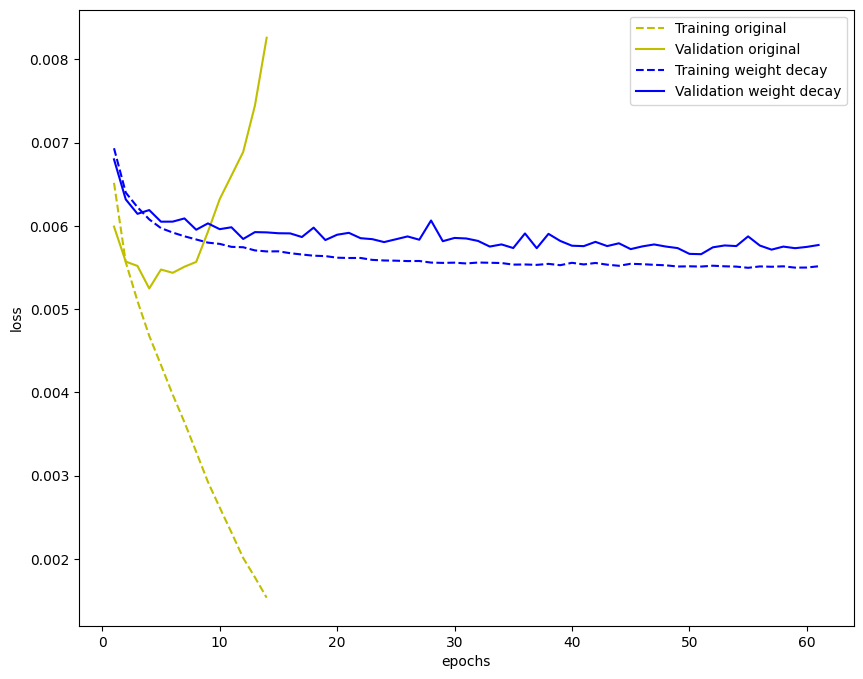

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr_loss)+1),tr_loss, linestyle = '--', color = 'y', label='Training original')
plt.plot(range(1,len(te_loss)+1),te_loss, color = 'y', label='Validation original')
plt.plot(range(1,len(tr1_loss)+1),tr1_loss, linestyle = '--', color = 'b', label='Training weight decay')
plt.plot(range(1,len(te1_loss)+1),te1_loss, color = 'b', label='Validation weight decay')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()